# BLEU Score 완전 분석 및 구현

## BLEU란? (Bilingual Evaluation Understudy)

> Papineni et al. (2002) 「BLEU: a Method for Automatic Evaluation of Machine Translation」

기계 번역 결과와 사람이 작성한 정답 번역문의 **n-gram 겹침** 정도를 측정

---

## BLEU 계산 공식

$$\text{BLEU} = \underbrace{\text{BP}}_{\text{Brevity Penalty}} \times \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

**구성 요소:**

| 요소 | 수식 | 의미 |
|------|------|------|
| $p_n$ | $\frac{\text{Clip}(\text{예측 n-gram 매칭 수})}{\text{예측 n-gram 전체 수}}$ | n-gram 정밀도 |
| BP | $\min(1, e^{1-r/c})$ | 짧은 번역 페널티 |
| $w_n$ | $1/N$ (보통 $1/4$) | n-gram 가중치 |

**Clipping**: 동일 n-gram이 정답에 1번 등장하면 예측에서 여러 번 나와도 1번만 인정

```
예시:
  정답: "the cat is on the mat"
  예측: "the the the the the"  ← 나쁜 번역

  클리핑 없이: p1 = 5/5 = 1.0  (the가 정답에 2번 → 예측 5번 모두 인정)
  클리핑 적용: p1 = 2/5 = 0.4  (정답에 2번 등장 → 최대 2번만 인정)
```

In [1]:
# ── 한글 폰트 설정 ──────────────────────────────────────────
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

!pip install nltk sacrebleu --quiet

import math, re
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
import sacrebleu
import warnings
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)

print('✅ 설치 완료')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.0 MB/s eta 0:00:00
✅ 설치 완료


## 1️⃣ BLEU 핵심 구성요소 — 단계별 구현

In [2]:
# ── Step 1: N-gram 추출 ──────────────────────────────────────
def get_ngrams(tokens, n):
    """토큰 리스트에서 n-gram Counter 반환"""
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))


# ── Step 2: Clipped n-gram Precision ────────────────────────
def clipped_ngram_precision(hypothesis, references, n):
    """
    수식: p_n = Σ_sentence [Σ_ngram min(count, max_ref_count)] / Σ_sentence [count_hyp]

    Clipping: 동일 n-gram이 예측에 5번 나와도 정답에 최대 2번이면 2번만 인정
    """
    clipped_count = 0
    total_count   = 0

    hyp_ngrams = get_ngrams(hypothesis, n)
    total_count += sum(hyp_ngrams.values())

    # 여러 정답 중 최대값으로 클리핑
    max_ref_counts = Counter()
    for ref in references:
        ref_ngrams = get_ngrams(ref, n)
        for ngram, count in ref_ngrams.items():
            max_ref_counts[ngram] = max(max_ref_counts[ngram], count)

    for ngram, count in hyp_ngrams.items():
        clipped_count += min(count, max_ref_counts.get(ngram, 0))

    return clipped_count, total_count


# ── Step 3: Brevity Penalty ─────────────────────────────────
def brevity_penalty(hypothesis_len, reference_len):
    """
    BP = 1                   if c > r  (예측이 더 길면 페널티 없음)
    BP = exp(1 - r/c)        if c ≤ r  (예측이 짧으면 페널티)
    """
    if hypothesis_len >= reference_len:
        return 1.0
    if hypothesis_len == 0:
        return 0.0
    return math.exp(1 - reference_len / hypothesis_len)


# ── Step 4: BLEU 통합 계산 ───────────────────────────────────
def compute_bleu(hypothesis, references, max_n=4, weights=None, smooth=False):
    """
    BLEU-{max_n} 계산 (직접 구현)

    hypothesis: 예측 토큰 리스트
    references: 정답 토큰 리스트의 리스트
    max_n:      최대 n-gram 차수 (BLEU-4 기본)
    smooth:     스무딩 (짧은 문장의 0 점수 방지)
    """
    if weights is None:
        weights = [1.0/max_n] * max_n

    if len(hypothesis) == 0:
        return 0.0, [0.0]*max_n, 0.0

    # n-gram 정밀도 계산
    precisions = []
    for n in range(1, max_n+1):
        clip, total = clipped_ngram_precision(hypothesis, references, n)
        if total == 0:
            precisions.append(0.0)
        elif clip == 0:
            if smooth:
                precisions.append(1.0 / (2**n * total))  # Lin et al. 스무딩
            else:
                precisions.append(0.0)
        else:
            precisions.append(clip / total)

    # Brevity Penalty
    hyp_len = len(hypothesis)
    ref_len = min(len(ref) for ref in references)  # 가장 짧은 정답 기준
    bp = brevity_penalty(hyp_len, ref_len)

    # BLEU 계산
    if 0.0 in precisions and not smooth:
        bleu = 0.0
    else:
        log_sum = sum(w * math.log(p + 1e-10)
                      for w, p in zip(weights, precisions))
        bleu = bp * math.exp(log_sum)

    return bleu, precisions, bp


# ── 단계별 계산 예시 ─────────────────────────────────────────
hypothesis  = "the cat sat on the mat".split()
reference1  = "the cat is sitting on the mat".split()
reference2  = "there is a cat on the mat".split()

bleu, precs, bp = compute_bleu(hypothesis, [reference1, reference2])

print('[BLEU 단계별 계산 예시]\n')
print(f'예측: {" ".join(hypothesis)}')
print(f'정답1: {" ".join(reference1)}')
print(f'정답2: {" ".join(reference2)}')
print()
for n, p in enumerate(precs, 1):
    clip, total = clipped_ngram_precision(hypothesis, [reference1, reference2], n)
    print(f'  p{n} (BLEU-{n}): {clip}/{total} = {p:.4f}')
print(f'  BP: {bp:.4f}  (예측길이={len(hypothesis)}, 정답길이={len(reference1)})')
print(f'\n  BLEU-4: {bleu:.4f}  ({bleu*100:.2f})')

[BLEU 단계별 계산 예시]

예측: the cat sat on the mat
정답1: the cat is sitting on the mat
정답2: there is a cat on the mat

  p1 (BLEU-1): 5/6 = 0.8333
  p2 (BLEU-2): 3/5 = 0.6000
  p3 (BLEU-3): 1/4 = 0.2500
  p4 (BLEU-4): 0/3 = 0.0000
  BP: 0.8465  (예측길이=6, 정답길이=7)

  BLEU-4: 0.0000  (0.00)


## 2️⃣ Clipping 효과 시각화

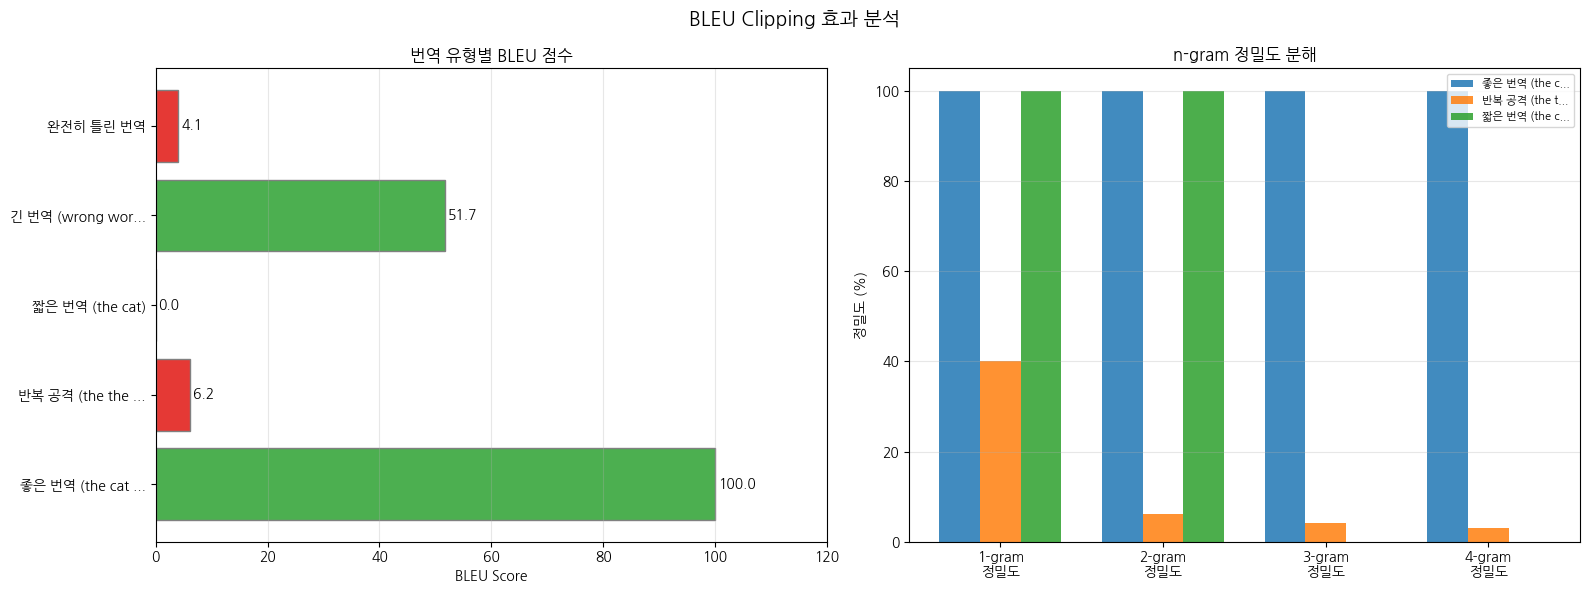

In [3]:
# Clipping의 중요성 시각화
ref = "the cat is on the mat".split()
hyps = {
    '좋은 번역 (the cat is on the mat)':   "the cat is on the mat".split(),
    '반복 공격 (the the the the the)':     "the the the the the".split(),
    '짧은 번역 (the cat)':                  "the cat".split(),
    '긴 번역 (wrong words added)':          "the cat is on the mat in the morning sun".split(),
    '완전히 틀린 번역':                      "i love beautiful weather today here".split(),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

results = {}
for name, hyp in hyps.items():
    bleu, precs, bp = compute_bleu(hyp, [ref], smooth=True)
    results[name] = {'bleu': bleu, 'precs': precs, 'bp': bp}

# BLEU 점수 막대 그래프
names  = [n[:15]+'...' if len(n)>15 else n for n in hyps.keys()]
scores = [results[n]['bleu']*100 for n in hyps.keys()]
colors = ['#4CAF50' if s>50 else ('#FF9800' if s>20 else '#E53935') for s in scores]
bars = axes[0].barh(names, scores, color=colors, edgecolor='gray')
for bar, s in zip(bars, scores):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'{s:.1f}', va='center', fontweight='bold')
axes[0].set_title('번역 유형별 BLEU 점수', fontweight='bold')
axes[0].set_xlabel('BLEU Score')
axes[0].set_xlim(0, 120)
axes[0].grid(axis='x', alpha=0.3)

# n-gram 정밀도 분해
selected = ['좋은 번역 (the cat is on the mat)', '반복 공격 (the the the the the)', '짧은 번역 (the cat)']
x = np.arange(4)
w = 0.25
for i, name in enumerate(selected):
    precs = [p*100 for p in results[name]['precs']]
    axes[1].bar(x + i*w, precs, w, label=name[:12]+'...', alpha=0.85)

axes[1].set_xticks(x + w)
axes[1].set_xticklabels(['1-gram\n정밀도', '2-gram\n정밀도', '3-gram\n정밀도', '4-gram\n정밀도'])
axes[1].set_title('n-gram 정밀도 분해', fontweight='bold')
axes[1].set_ylabel('정밀도 (%)')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('BLEU Clipping 효과 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bleu_clipping.png', dpi=150, bbox_inches='tight')
plt.show()

## 3️⃣ Brevity Penalty 분석

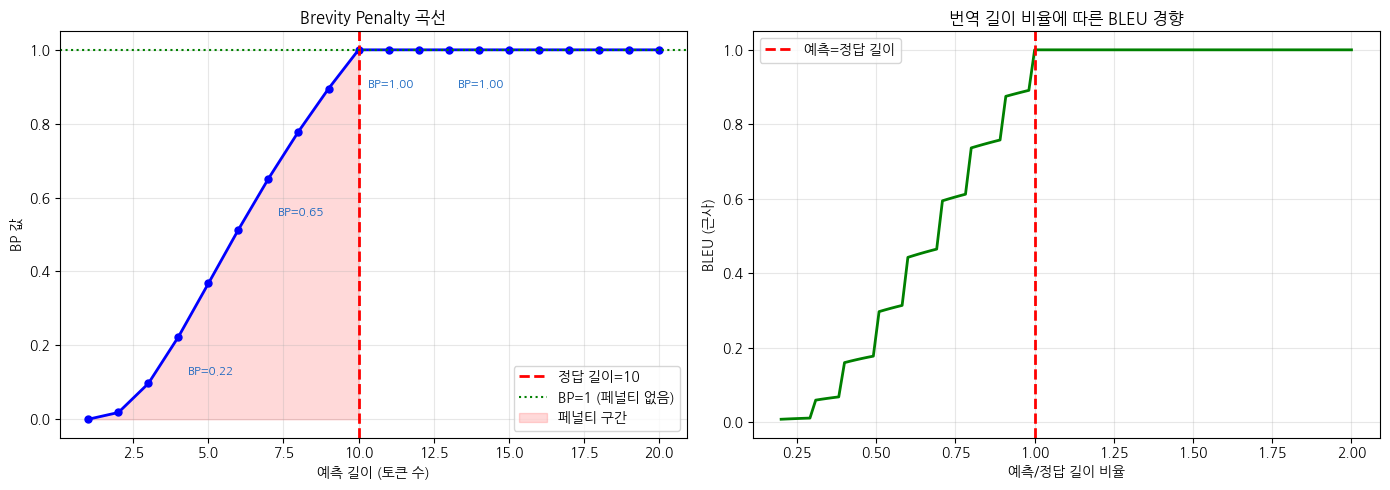

[Brevity Penalty 직관]
  예측길이 < 정답길이: BP < 1 (짧은 번역 페널티)
  예측길이 = 정답길이: BP = 1 (페널티 없음)
  예측길이 > 정답길이: BP = 1 (긴 번역은 페널티 없음 — n-gram 정밀도로 자연히 낮아짐)


In [5]:
import math, re
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
import sacrebleu
import warnings
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)


def get_ngrams(tokens, n):
    """토큰 리스트에서 n-gram Counter 반환"""
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))


def clipped_ngram_precision(hypothesis, references, n):
    """
    수식: p_n = Σ_sentence [Σ_ngram min(count, max_ref_count)] / Σ_sentence [count_hyp]

    Clipping: 동일 n-gram이 예측에 5번 나와도 정답에 최대 2번이면 2번만 인정
    """
    clipped_count = 0
    total_count   = 0

    hyp_ngrams = get_ngrams(hypothesis, n)
    total_count += sum(hyp_ngrams.values())

    # 여러 정답 중 최대값으로 클리핑
    max_ref_counts = Counter()
    for ref in references:
        ref_ngrams = get_ngrams(ref, n)
        for ngram, count in ref_ngrams.items():
            max_ref_counts[ngram] = max(max_ref_counts[ngram], count)

    for ngram, count in hyp_ngrams.items():
        clipped_count += min(count, max_ref_counts.get(ngram, 0))

    return clipped_count, total_count


def brevity_penalty(hypothesis_len, reference_len):
    """
    BP = 1                   if c > r  (예측이 더 길면 페널티 없음)
    BP = exp(1 - r/c)        if c ≤ r  (예측이 짧으면 페널티)
    """
    if hypothesis_len >= reference_len:
        return 1.0
    if hypothesis_len == 0:
        return 0.0
    return math.exp(1 - reference_len / hypothesis_len)


# BP 곡선
ref_len = 10
hyp_lens = list(range(1, 21))
bps = [brevity_penalty(h, ref_len) for h in hyp_lens]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hyp_lens, bps, 'b-o', ms=5, lw=2)
axes[0].axvline(ref_len, color='red', linestyle='--', lw=2, label=f'정답 길이={ref_len}')
axes[0].axhline(1.0, color='green', linestyle=':', lw=1.5, label='BP=1 (페널티 없음)')
axes[0].fill_between(hyp_lens[:ref_len], [0] * ref_len, bps[:ref_len], alpha=0.15, color='red', label='페널티 구간')
axes[0].set_title('Brevity Penalty 곡선', fontweight='bold')
axes[0].set_xlabel('예측 길이 (토큰 수)')
axes[0].set_ylabel('BP 값')
axes[0].legend(); axes[0].grid(alpha=0.3)

# BP 임계점 표시
for hlen in [4, 7, 10, 13]:
    bp_val = brevity_penalty(hlen, ref_len)
    axes[0].annotate(f'BP={bp_val:.2f}',
                     xy=(hlen, bp_val), xytext=(hlen+0.3, bp_val-0.1),
                     fontsize=8.5, color='#1565C0')

# BLEU vs 번역 길이 비율
ratios = np.linspace(0.2, 2.0, 100)
bleus  = [brevity_penalty(int(r*10), 10) * (0.8**(max(0, 1/r - 1)))
          for r in ratios]
axes[1].plot(ratios, bleus, 'g-', lw=2)
axes[1].axvline(1.0, color='red', linestyle='--', lw=2, label='예측=정답 길이')
axes[1].set_title('번역 길이 비율에 따른 BLEU 경향', fontweight='bold')
axes[1].set_xlabel('예측/정답 길이 비율')
axes[1].set_ylabel('BLEU (근사)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bleu_bp.png', dpi=150, bbox_inches='tight')
plt.show()

print('[Brevity Penalty 직관]')
print('  예측길이 < 정답길이: BP < 1 (짧은 번역 페널티)')
print('  예측길이 = 정답길이: BP = 1 (페널티 없음)')
print('  예측길이 > 정답길이: BP = 1 (긴 번역은 페널티 없음 — n-gram 정밀도로 자연히 낮아짐)')

## 4️⃣ 한국어 번역 모델 평가 실습

In [6]:
# 실제 번역 평가 데이터 (영→한)
EVAL_DATA = [
    {
        'source':    'I go to school every day.',
        'reference': ['나 는 매일 학교 에 간다 .', '나 는 매일 학교 를 다닌다 .'],
        'model_A':   '나 는 매일 학교 에 간다 .',        # 완벽
        'model_B':   '나 는 학교 에 간다 .',             # 매일 빠짐
        'model_C':   '나 학교 간다 .',                   # 조사 빠짐
        'model_D':   '우리 는 매일 학교 로 이동 합니다 .', # 의미는 비슷하나 다른 표현
    },
    {
        'source':    'She likes reading books.',
        'reference': ['그녀 는 책 읽기 를 좋아한다 .', '그녀 는 독서 를 즐긴다 .'],
        'model_A':   '그녀 는 책 을 읽는 것 을 좋아한다 .',
        'model_B':   '그녀 는 책 읽기 를 좋아한다 .',
        'model_C':   '그 여자 는 책 좋아 해 .',
        'model_D':   '그녀 독서 좋아 .',
    },
    {
        'source':    'The weather is nice today.',
        'reference': ['오늘 날씨 가 맑다 .', '오늘 날씨 가 좋다 .'],
        'model_A':   '오늘 날씨 가 좋다 .',
        'model_B':   '오늘 날씨 맑아 .',
        'model_C':   '날씨 좋은 하루 야 .',
        'model_D':   '오늘 은 매우 화창 하고 아름다운 날씨 입니다 .',
    },
    {
        'source':    'Deep learning changed the world.',
        'reference': ['딥러닝 이 세상 을 바꿨다 .', '딥 러닝 이 세계 를 변화 시켰다 .'],
        'model_A':   '딥러닝 이 세상 을 바꿨다 .',
        'model_B':   '딥러닝 은 세상 을 바꾸었다 .',
        'model_C':   '딥 러닝 이 세상 을 바꿨습니다 .',
        'model_D':   '인공지능 기술 이 전 세계 를 혁신 시켰다 .',
    },
]

def evaluate_models(eval_data):
    model_names = ['model_A','model_B','model_C','model_D']
    results = {m: {'bleu1':[],'bleu2':[],'bleu4':[],'bp':[]} for m in model_names}

    print(f"{'소스':>28} | {'모델':>7} | {'BLEU-1':>7} | {'BLEU-2':>7} | {'BLEU-4':>7} | {'BP':>5}")
    print('='*75)

    for item in eval_data:
        refs = [r.split() for r in item['reference']]
        src  = item['source'][:25] + '...'

        for mname in model_names:
            hyp = item[mname].split()
            b1, _, bp1 = compute_bleu(hyp, refs, max_n=1, smooth=True)
            b2, _, bp2 = compute_bleu(hyp, refs, max_n=2, smooth=True)
            b4, precs, bp4 = compute_bleu(hyp, refs, max_n=4, smooth=True)

            results[mname]['bleu1'].append(b1)
            results[mname]['bleu2'].append(b2)
            results[mname]['bleu4'].append(b4)
            results[mname]['bp'].append(bp4)

            print(f"{src:>28} | {mname:>7} | {b1*100:>7.2f} | {b2*100:>7.2f} | {b4*100:>7.2f} | {bp4:>5.3f}")

        print('-'*75)

    return results

results = evaluate_models(EVAL_DATA)

                          소스 |      모델 |  BLEU-1 |  BLEU-2 |  BLEU-4 |    BP
I go to school every day.... | model_A |  100.00 |  100.00 |  100.00 | 1.000
I go to school every day.... | model_B |   84.65 |   75.71 |   51.15 | 0.846
I go to school every day.... | model_C |   47.24 |   27.27 |    8.97 | 0.472
I go to school every day.... | model_D |   50.00 |   37.80 |   13.13 | 1.000
---------------------------------------------------------------------------
 She likes reading books.... | model_A |   55.56 |   45.64 |   13.27 | 1.000
 She likes reading books.... | model_B |  100.00 |  100.00 |  100.00 | 1.000
 She likes reading books.... | model_C |   42.86 |   26.73 |    7.27 | 1.000
 She likes reading books.... | model_D |   45.49 |   15.16 |    7.58 | 0.607
---------------------------------------------------------------------------
The weather is nice today... | model_A |  100.00 |  100.00 |  100.00 | 1.000
The weather is nice today... | model_B |   58.41 |   38.94 |   13.77 | 0.779
T

In [7]:
# Corpus-level BLEU 계산 (문장 단위 평균이 아님!)
model_names = ['model_A','model_B','model_C','model_D']

print('[Corpus-level BLEU vs Sentence-level BLEU 평균]\n')
print('⚠️  주의: BLEU는 말뭉치(Corpus) 단위 계산이 올바름!')
print('    문장별 평균은 짧은 문장에 과도한 가중치 부여 문제 발생\n')

corpus_results = {}
for mname in model_names:
    # Corpus BLEU (전체 문서 통합 계산)
    all_hyps = [item[mname].split() for item in EVAL_DATA]
    all_refs  = [[r.split() for r in item['reference']] for item in EVAL_DATA]

    # 직접 구현 Corpus BLEU
    total_clipped = [0] * 4
    total_count   = [0] * 4
    total_hyp_len = 0
    total_ref_len = 0

    for hyp, refs in zip(all_hyps, all_refs):
        total_hyp_len += len(hyp)
        total_ref_len += min(len(r) for r in refs)
        for n in range(1, 5):
            clip, total = clipped_ngram_precision(hyp, refs, n)
            total_clipped[n-1] += clip
            total_count[n-1]   += total

    precisions = [c/t if t>0 else 0 for c, t in zip(total_clipped, total_count)]
    bp_corpus  = brevity_penalty(total_hyp_len, total_ref_len)

    if all(p > 0 for p in precisions):
        log_sum = sum(0.25 * math.log(p) for p in precisions)
        corpus_bleu_score = bp_corpus * math.exp(log_sum)
    else:
        corpus_bleu_score = 0.0

    sent_avg = np.mean(results[mname]['bleu4'])
    corpus_results[mname] = corpus_bleu_score

    print(f'{mname}: Corpus-BLEU={corpus_bleu_score*100:.2f}  |  Sentence-avg={sent_avg*100:.2f}')

best_model = max(corpus_results, key=corpus_results.get)
print(f'\n✅ 최고 성능 모델: {best_model} (Corpus-BLEU={corpus_results[best_model]*100:.2f})')

[Corpus-level BLEU vs Sentence-level BLEU 평균]

⚠️  주의: BLEU는 말뭉치(Corpus) 단위 계산이 올바름!
    문장별 평균은 짧은 문장에 과도한 가중치 부여 문제 발생

model_A: Corpus-BLEU=72.33  |  Sentence-avg=78.32
model_B: Corpus-BLEU=55.94  |  Sentence-avg=43.64
model_C: Corpus-BLEU=0.00  |  Sentence-avg=12.06
model_D: Corpus-BLEU=0.00  |  Sentence-avg=7.89

✅ 최고 성능 모델: model_A (Corpus-BLEU=72.33)


## 5️⃣ Smoothing 기법 비교

[스무딩 기법별 BLEU 비교 (짧은 문장)]

                            예측 |         스무딩 없음 |  Method1 (Lin) |        Method2 |        Method4
-----------------------------------------------------------------------------------------------
                       고 양 이  |           0.00 |          10.62 |          15.88 |          10.87 | 
                     고 양 이 가  |          36.79 |          36.79 |          36.79 |          36.79 | 
                 고 양 이 가 앉 아  |          71.65 |          71.65 |          71.65 |          71.65 | 
             고 양 이 가 앉 아 있 다  |         100.00 |         100.00 |         100.00 |         100.00 | 


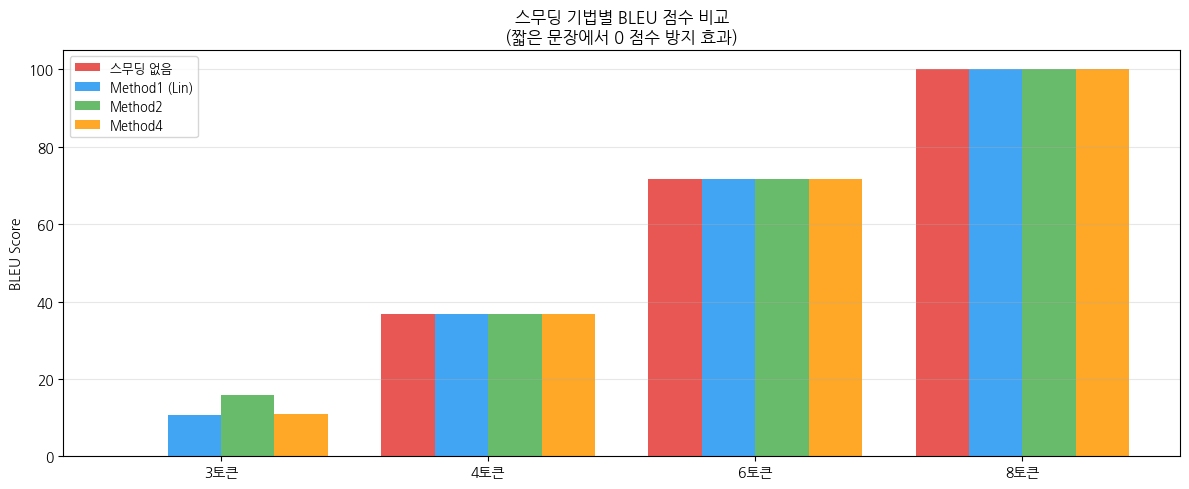

In [10]:
from nltk.translate.bleu_score import SmoothingFunction

# 짧은 문장에서 스무딩의 영향
short_ref  = ['고 양 이 가 앉 아 있 다'.split()]
short_hyps = [
    '고 양 이'.split(),           # 3토큰
    '고 양 이 가'.split(),         # 4토큰
    '고 양 이 가 앉 아'.split(),   # 6토큰
    '고 양 이 가 앉 아 있 다'.split(), # 전체
]

sf = SmoothingFunction()
smooth_methods = {
    '스무딩 없음':     lambda h,r: sentence_bleu(r, h),
    'Method1 (Lin)':   lambda h,r: sentence_bleu(r, h, smoothing_function=sf.method1),
    'Method2':         lambda h,r: sentence_bleu(r, h, smoothing_function=sf.method2),
    'Method4':         lambda h,r: sentence_bleu(r, h, smoothing_function=sf.method4),
}

print('[스무딩 기법별 BLEU 비교 (짧은 문장)]\n')
print(f'{"예측":>30} | ' + ' | '.join(f'{k:>14}' for k in smooth_methods))
print('-' * 95)

plot_data = {k: [] for k in smooth_methods}
for hyp in short_hyps:
    row = f'  {" ".join(hyp):>26}  | '
    for method_name, fn in smooth_methods.items():
        score = fn(hyp, short_ref)
        row += f'{score*100:>14.2f} | '
        plot_data[method_name].append(score*100)
    print(row)

# 시각화
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(short_hyps))
w = 0.2
colors = ['#E53935','#2196F3','#4CAF50','#FF9800']

for i, (name, vals) in enumerate(plot_data.items()):
    bars = ax.bar(x + i*w, vals, w, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels([f'{len(h)}토큰' for h in short_hyps])
ax.set_title('스무딩 기법별 BLEU 점수 비교\n(짧은 문장에서 0 점수 방지 효과)', fontweight='bold')
ax.set_ylabel('BLEU Score')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bleu_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ SacreBLEU — 표준화된 BLEU 계산

In [11]:
import sacrebleu

# SacreBLEU: 토크나이저 표준화 + 재현 가능한 BLEU
sys_translations = [
    item['model_A'] for item in EVAL_DATA
]
ref_translations_1 = [
    item['reference'][0] for item in EVAL_DATA
]

# SacreBLEU 계산
bleu_obj = sacrebleu.corpus_bleu(sys_translations, [ref_translations_1])

print('[SacreBLEU 결과 (model_A)]\n')
print(f'  BLEU:       {bleu_obj.score:.2f}')
print(f'  1-gram P:   {bleu_obj.precisions[0]:.2f}%')
print(f'  2-gram P:   {bleu_obj.precisions[1]:.2f}%')
print(f'  3-gram P:   {bleu_obj.precisions[2]:.2f}%')
print(f'  4-gram P:   {bleu_obj.precisions[3]:.2f}%')
print(f'  BP:         {bleu_obj.bp:.4f}')
print(f'  hyp_len:    {bleu_obj.sys_len}')
print(f'  ref_len:    {bleu_obj.ref_len}')
print()
print('[모든 모델 SacreBLEU 비교]\n')

for mname in ['model_A','model_B','model_C','model_D']:
    hyps = [item[mname] for item in EVAL_DATA]
    b = sacrebleu.corpus_bleu(hyps, [ref_translations_1])
    print(f'  {mname}: BLEU={b.score:>6.2f}  BP={b.bp:.3f}  1g={b.precisions[0]:.1f}  2g={b.precisions[1]:.1f}')

[SacreBLEU 결과 (model_A)]

  BLEU:       62.56
  1-gram P:   81.48%
  2-gram P:   69.57%
  3-gram P:   57.89%
  4-gram P:   46.67%
  BP:         1.0000
  hyp_len:    27
  ref_len:    25

[모든 모델 SacreBLEU 비교]

  model_A: BLEU= 62.56  BP=1.000  1g=81.5  2g=69.6
  model_B: BLEU= 53.56  BP=0.917  1g=87.0  2g=63.2
  model_C: BLEU= 12.63  BP=0.917  1g=56.5  2g=21.1
  model_D: BLEU=  7.73  BP=1.000  1g=36.7  2g=7.7


## 7️⃣ BLEU의 한계와 보완 지표

In [12]:
# BLEU의 한계 시각화
limit_examples = [
    ('정답',                         '오늘 날씨 가 매우 좋습니다.'),
    ('동의어 사용 (좋음→맑음)',        '오늘 날씨 가 매우 맑습니다.'),
    ('어순 변경',                    '날씨 가 오늘 매우 좋습니다.'),
    ('완전히 다른 표현 (의미 같음)',   '오늘 은 날씨 가 정말 화창 해요.'),
    ('n-gram 우연히 일치',            '날씨 가 매우 다양한 요인 으로 좋아요.'),
]

ref = [['오늘 날씨 가 매우 좋습니다.'.split()]]

print('[BLEU 한계 예시]\n')
for desc, hyp_str in limit_examples:
    hyp   = hyp_str.split()
    score = sentence_bleu(ref[0], hyp, smoothing_function=SmoothingFunction().method1)
    print(f'  {desc:<25}: "{hyp_str}"')
    print(f'  → BLEU = {score:.4f}\n')

# 보완 지표 비교표
metrics_comparison = pd.DataFrame({
    '지표':        ['BLEU', 'METEOR', 'ROUGE-L', 'BERTScore', 'COMET'],
    '측정 방식':   ['n-gram 정밀도', '단어 매칭+동의어', 'LCS 기반 재현율', '임베딩 코사인 유사도', '신경망 품질 예측'],
    '동의어 처리': ['❌', '✅ (WordNet)', '❌', '✅ (BERT)', '✅'],
    '의미 이해':   ['❌', '△', '❌', '✅', '✅✅'],
    '계산 속도':   ['⚡⚡⚡', '⚡⚡', '⚡⚡', '⚡', '⚡'],
    '주요 사용':   ['MT 표준', 'MT/QA', '요약', 'MT/요약', 'MT 최신 표준'],
})
print('[번역 평가 지표 비교]\n')
print(metrics_comparison.to_string(index=False))

print("""
💡 BLEU 해석 가이드 (기계 번역 기준):
  < 10  : 이해 불가 수준
  10~19 : 대략적인 의미 전달
  20~29 : 실용적 번역 가능
  30~40 : 좋은 번역
  40~50 : 매우 좋은 번역
  50~60 : 품질 번역 (전문 번역가 수준)
  > 60  : 과적합 의심 또는 쉬운 도메인
""")

[BLEU 한계 예시]

  정답                       : "오늘 날씨 가 매우 좋습니다."
  → BLEU = 1.0000

  동의어 사용 (좋음→맑음)           : "오늘 날씨 가 매우 맑습니다."
  → BLEU = 0.6687

  어순 변경                    : "날씨 가 오늘 매우 좋습니다."
  → BLEU = 0.1699

  완전히 다른 표현 (의미 같음)        : "오늘 은 날씨 가 정말 화창 해요."
  → BLEU = 0.0773

  n-gram 우연히 일치            : "날씨 가 매우 다양한 요인 으로 좋아요."
  → BLEU = 0.1635

[번역 평가 지표 비교]

       지표       측정 방식      동의어 처리 의미 이해 계산 속도    주요 사용
     BLEU  n-gram 정밀도           ❌     ❌   ⚡⚡⚡    MT 표준
   METEOR   단어 매칭+동의어 ✅ (WordNet)     △    ⚡⚡    MT/QA
  ROUGE-L  LCS 기반 재현율           ❌     ❌    ⚡⚡       요약
BERTScore 임베딩 코사인 유사도    ✅ (BERT)     ✅     ⚡    MT/요약
    COMET   신경망 품질 예측           ✅    ✅✅     ⚡ MT 최신 표준

💡 BLEU 해석 가이드 (기계 번역 기준):
  < 10  : 이해 불가 수준
  10~19 : 대략적인 의미 전달
  20~29 : 실용적 번역 가능
  30~40 : 좋은 번역
  40~50 : 매우 좋은 번역
  50~60 : 품질 번역 (전문 번역가 수준)
  > 60  : 과적합 의심 또는 쉬운 도메인

